<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/M%C3%B4_h%C3%ACnh_MLP_Dry_Bean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
pd_train = pd.read_csv("https://raw.githubusercontent.com/thuynguyenhuit/hocsau/refs/heads/main/Dry_Bean_Dataset.csv")

In [46]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim

In [47]:
pd_train.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [48]:
# =========================================
# 3. KIỂM TRA DỮ LIỆU
# =========================================
print(pd_train.info())

print(pd_train["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [49]:
# =========================================
# Mã hóa nhãn (Label Encoding) cho biến mục tiêu
# =========================================

encoder = LabelEncoder()

pd_train["Class"] = encoder.fit_transform(pd_train["Class"])

print(pd_train.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

In [50]:
# =========================================
# 5. TÁCH X VÀ y
# =========================================

X = pd_train.drop("Class", axis=1)

y = pd_train["Class"]

In [51]:
# =========================================
# 6. CHIA TRAIN / VAL / TEST
# Train: 70%, Val: 15%, Test: 15%
# =========================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

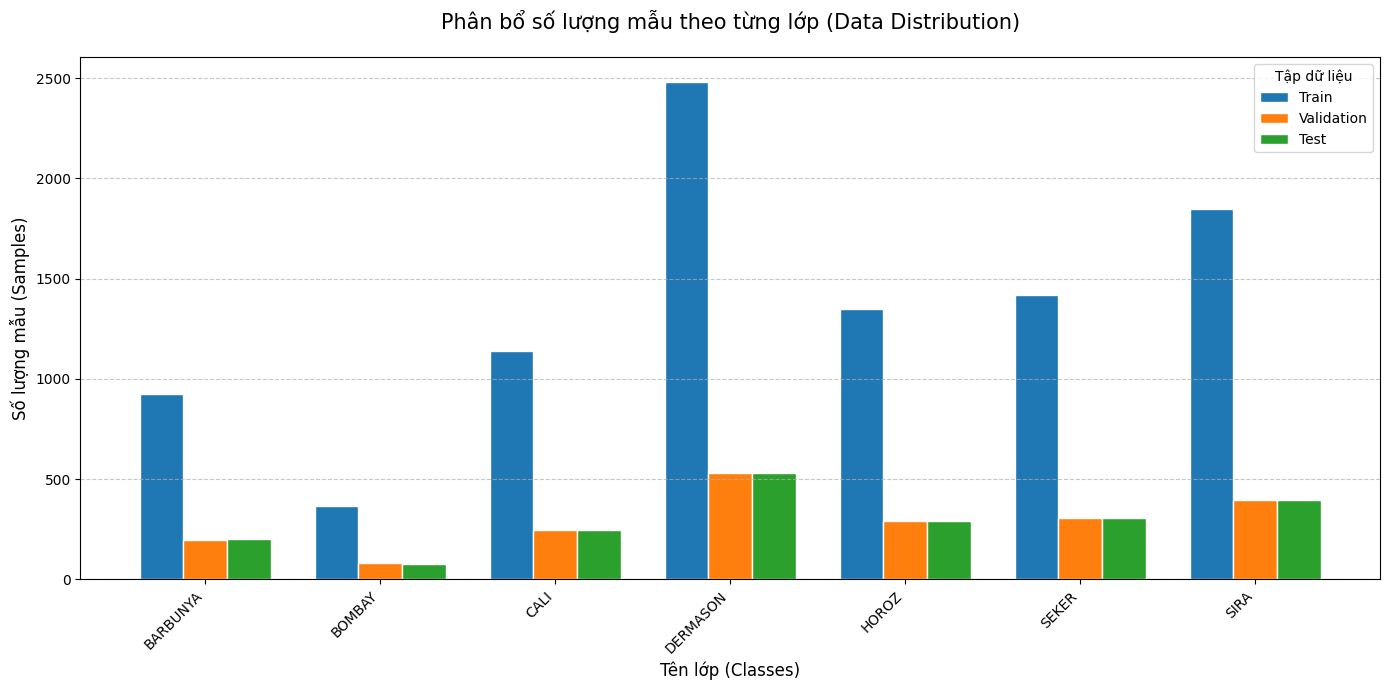

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================
# 1. ĐẾM SỐ LƯỢNG MẪU (Trực tiếp từ Series)
# =========================================
# Giả định y_train, y_val, y_test là các Pandas Series
# Nếu chúng là Tensor, hãy dùng .to_numpy() trước khi đếm

train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# =========================================
# 2. CLASS NAMES
# =========================================
# Lấy tên các lớp từ LabelEncoder bạn đã dùng trước đó
class_names = encoder.classes_

# =========================================
# 3. VẼ BIỂU ĐỒ CỘT (GROUPED BAR CHART)
# =========================================
x = range(len(class_names))
width = 0.25  # Độ rộng của mỗi cột

plt.figure(figsize=(14, 7))

# Vẽ từng nhóm cột cho Train, Validation, Test
plt.bar(
    [i - width for i in x],
    train_counts,
    width=width,
    label='Train',
    color='#1f77b4',
    edgecolor='white'
)

plt.bar(
    x,
    val_counts,
    width=width,
    label='Validation',
    color='#ff7f0e',
    edgecolor='white'
)

plt.bar(
    [i + width for i in x],
    test_counts,
    width=width,
    label='Test',
    color='#2ca02c',
    edgecolor='white'
)

# =========================================
# 4. TRÌNH BÀY (LABELS & STYLE)
# =========================================
plt.title("Phân bổ số lượng mẫu theo từng lớp (Data Distribution)", fontsize=15, pad=20)
plt.xlabel("Tên lớp (Classes)", fontsize=12)
plt.ylabel("Số lượng mẫu (Samples)", fontsize=12)

# Thiết lập nhãn trục X
plt.xticks(x, class_names, rotation=45, ha='right')

# Thêm chú thích
plt.legend(title="Tập dữ liệu")

# Thêm lưới ngang để dễ quan sát số lượng
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tự động căn chỉnh để không bị mất nhãn phía dưới
plt.tight_layout()

plt.show()

In [53]:
# Thêm phiên bản SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [54]:
# =========================================
# 7. SCALE FEATURES
# =========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [55]:
# =========================================
# 8. CHUYỂN SANG TENSOR
# Sau khi hoàn thành bước chuẩn hóa dữ liệu, các tập dữ liệu huấn luyện, validation và kiểm tra được chuyển đổi sang Tensor
# bằng thư viện PyTorch PyTorch để phục vụ quá trình huấn luyện mô hình MLP.
# Các đặc trưng đầu vào được chuyển sang kiểu dữ liệu float32 nhằm đảm bảo tính toán số thực trong quá trình
# lan truyền tiến và lan truyền ngược của mạng neural.
# Đồng thời, các nhãn phân loại được chuyển sang kiểu long để tương thích với hàm mất mát CrossEntropyLoss trong bài toán phân loại đa lớp.
# Việc chuyển đổi sang Tensor giúp PyTorch có thể thực hiện các phép toán ma trận, tối ưu hóa gradient và huấn luyện mô hình một cách hiệu quả trên CPU hoặc GPU.
# =========================================

X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)


y_train = torch.tensor(y_train.values, dtype=torch.long)

y_val = torch.tensor(y_val.values, dtype=torch.long)

y_test = torch.tensor(y_test.values, dtype=torch.long)

X_train_smote = torch.tensor(
    X_train_smote,
    dtype=torch.float32
)

y_train_smote = torch.tensor(
    y_train_smote,
    dtype=torch.long
)

ValueError: could not determine the shape of object type 'DataFrame'

In [57]:
import numpy as np
import pandas as pd
import torch

X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_val_tensor   = torch.tensor(np.array(X_val), dtype=torch.float32)
X_test_tensor  = torch.tensor(np.array(X_test), dtype=torch.float32)

y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
y_val_tensor   = torch.tensor(np.array(y_val), dtype=torch.long)
y_test_tensor  = torch.tensor(np.array(y_test), dtype=torch.long)

# ==========================================
# 2. Chuyển đổi tập dữ liệu sau khi SMOTE
# ==========================================
X_train_smote_tensor = torch.tensor(np.array(X_train_smote), dtype=torch.float32)
y_train_smote_tensor = torch.tensor(np.array(y_train_smote), dtype=torch.long)

# ==========================================
# 3. Kiểm tra lại kích thước
# ==========================================
print("--- Kích thước các Tensor tập gốc ---")
print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"X_val:   {X_val_tensor.shape}, y_val:   {y_val_tensor.shape}")
print(f"X_test:  {X_test_tensor.shape}, y_test:  {y_test_tensor.shape}")

print("\n--- Kích thước các Tensor sau SMOTE ---")
print(f"X_train_smote: {X_train_smote_tensor.shape}, y_train_smote: {y_train_smote_tensor.shape}")

--- Kích thước các Tensor tập gốc ---
X_train: torch.Size([9527, 16]), y_train: torch.Size([9527])
X_val:   torch.Size([2042, 16]), y_val:   torch.Size([2042])
X_test:  torch.Size([2042, 16]), y_test:  torch.Size([2042])

--- Kích thước các Tensor sau SMOTE ---
X_train_smote: torch.Size([17374, 16]), y_train_smote: torch.Size([17374])


In [58]:
# =========================================
# 9. INPUT SIZE
# =========================================

input_size = X_train.shape[1]

print(input_size)

16


MÔ HÌNH KHÔNG DROPOUT

In [59]:
# =========================================
# 10. MODEL KHÔNG DROPOUT
# =========================================

class MLP_NoDropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

MÔ HÌNH CÓ DROPOUT

In [60]:
# =========================================
# 11. MODEL CÓ DROPOUT
# =========================================

class MLP_Dropout(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 7)
        )

    def forward(self, x):
        return self.network(x)

TRAIN MODEL

In [61]:
# =========================================
# 12. HÀM TRAIN
# =========================================

def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=700
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # =========================
        # TRAIN
        # =========================

        model.train() #Bật chế độ "đang học"

        outputs = model(X_train) #Dự đoán thử trên tập dữ liệu học

        loss = criterion(outputs, y_train)

        optimizer.zero_grad() #Xóa các tính toán cũ để chuẩn bị cho vòng lặp mới (tránh cộng dồn sai số cũ).

        loss.backward() #Tính toán xem lỗi nằm ở đâu (Lan truyền ngược)

        optimizer.step() #Cập nhật trọng số của mô hình để lần sau không mắc lại lỗi cũ

        train_losses.append(loss.item())

        _, predicted = torch.max(outputs, 1)

        train_acc = (
            predicted == y_train
        ).float().mean()

        train_accuracies.append(
            train_acc.item()
        )

        # =========================
        # VALIDATION
        # =========================

        model.eval() # Lúc này Dropout sẽ bị tắt đi để dự đoán ổn định nhất.

        with torch.no_grad(): #Tạm dừng việc tính toán đạo hàm để tiết kiệm bộ nhớ và chạy nhanh hơn
                              #(vì lúc này chỉ kiểm tra chứ không cập nhật trọng số).

            val_outputs = model(X_val)

            val_loss = criterion(
                val_outputs,
                y_val
            )

            val_losses.append(
                val_loss.item()
            )
        #tìm giá trị lớn nhất theo hàng (chiều thứ 1), Nhận về vị trí (index) của giá trị lớn nhất đó
            _, val_predicted = torch.max(
                val_outputs,
                1
            )

            val_acc = (
                val_predicted == y_val #So sánh từng dự đoán với nhãn thực tế
            ).float().mean()

            val_accuracies.append(
                val_acc.item()
            )

        if (epoch + 1) % 50 == 0:

            print(
                f"Epoch {epoch+1}/{epochs}"
                f" | Train Loss: {loss.item():.4f}"
                f" | Val Loss: {val_loss.item():.4f}"
                f" | Train Acc: {train_acc.item():.4f}"
                f" | Val Acc: {val_acc.item():.4f}"
            )

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

TRAIN MODEL KHÔNG DROPOUT, KHÔNG SMOTE

In [69]:
# =========================================
# TRAIN NO DROPOUT, NO SMOTE
# =========================================

model_no_dropout = MLP_NoDropout(input_size)

(
    train_loss_no,
    val_loss_no,
    train_acc_no,
    val_acc_no

) = train_model(
    model_no_dropout,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.5731 | Val Loss: 0.5510 | Train Acc: 0.7922 | Val Acc: 0.8002
Epoch 100/700 | Train Loss: 0.2342 | Val Loss: 0.2313 | Train Acc: 0.9200 | Val Acc: 0.9202
Epoch 150/700 | Train Loss: 0.1984 | Val Loss: 0.2068 | Train Acc: 0.9281 | Val Acc: 0.9236
Epoch 200/700 | Train Loss: 0.1871 | Val Loss: 0.2010 | Train Acc: 0.9303 | Val Acc: 0.9270
Epoch 250/700 | Train Loss: 0.1805 | Val Loss: 0.1990 | Train Acc: 0.9328 | Val Acc: 0.9270
Epoch 300/700 | Train Loss: 0.1754 | Val Loss: 0.1975 | Train Acc: 0.9349 | Val Acc: 0.9256
Epoch 350/700 | Train Loss: 0.1710 | Val Loss: 0.1967 | Train Acc: 0.9369 | Val Acc: 0.9280
Epoch 400/700 | Train Loss: 0.1670 | Val Loss: 0.1962 | Train Acc: 0.9388 | Val Acc: 0.9285
Epoch 450/700 | Train Loss: 0.1629 | Val Loss: 0.1957 | Train Acc: 0.9412 | Val Acc: 0.9290
Epoch 500/700 | Train Loss: 0.1587 | Val Loss: 0.1959 | Train Acc: 0.9430 | Val Acc: 0.9285
Epoch 550/700 | Train Loss: 0.1549 | Val Loss: 0.1962 | Train Acc: 0.9446 | Val A

TRAIN MODEL CÓ DROPOUT, KHÔNG SMOTE

In [68]:
# =========================================
# TRAIN DROPOUT, NO SMOTE
# =========================================

model_dropout = MLP_Dropout(input_size)

(
    train_loss_drop,
    val_loss_drop,
    train_acc_drop,
    val_acc_drop
) = train_model(
    model_dropout,
    X_train_tensor,
    y_train_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 0.7697 | Val Loss: 0.6818 | Train Acc: 0.7098 | Val Acc: 0.7693
Epoch 100/700 | Train Loss: 0.3603 | Val Loss: 0.2807 | Train Acc: 0.8772 | Val Acc: 0.9011
Epoch 150/700 | Train Loss: 0.2766 | Val Loss: 0.2197 | Train Acc: 0.9055 | Val Acc: 0.9256
Epoch 200/700 | Train Loss: 0.2454 | Val Loss: 0.2098 | Train Acc: 0.9149 | Val Acc: 0.9261
Epoch 250/700 | Train Loss: 0.2364 | Val Loss: 0.2073 | Train Acc: 0.9196 | Val Acc: 0.9265
Epoch 300/700 | Train Loss: 0.2267 | Val Loss: 0.2051 | Train Acc: 0.9233 | Val Acc: 0.9256
Epoch 350/700 | Train Loss: 0.2171 | Val Loss: 0.2023 | Train Acc: 0.9230 | Val Acc: 0.9270
Epoch 400/700 | Train Loss: 0.2148 | Val Loss: 0.2014 | Train Acc: 0.9262 | Val Acc: 0.9265
Epoch 450/700 | Train Loss: 0.2106 | Val Loss: 0.2015 | Train Acc: 0.9263 | Val Acc: 0.9265
Epoch 500/700 | Train Loss: 0.2037 | Val Loss: 0.2006 | Train Acc: 0.9288 | Val Acc: 0.9285
Epoch 550/700 | Train Loss: 0.2067 | Val Loss: 0.2002 | Train Acc: 0.9272 | Val A

TRAIN MODEL KHÔNG DROPOUT, KHÔNG SMOTE

In [65]:
# =========================================
# TRAIN NO DROPOUT, SMOTE
# =========================================

model_no_dropout_smote = MLP_NoDropout(input_size)

(
    train_loss_no_smote,
    val_loss_no_smote,
    train_acc_no_smote,
    val_acc_no_smote
) = train_model(
    model_no_dropout_smote,
    X_train_smote_tensor,
    y_train_smote_tensor,
    X_val_tensor,
    y_val_tensor
)

Epoch 50/700 | Train Loss: 155.2509 | Val Loss: 1.9544 | Train Acc: 0.1429 | Val Acc: 0.1366
Epoch 100/700 | Train Loss: 51.6627 | Val Loss: 1.9492 | Train Acc: 0.1429 | Val Acc: 0.2512
Epoch 150/700 | Train Loss: 50.2682 | Val Loss: 1.9438 | Train Acc: 0.1429 | Val Acc: 0.2605
Epoch 200/700 | Train Loss: 50.7672 | Val Loss: 1.9399 | Train Acc: 0.1429 | Val Acc: 0.2605
Epoch 250/700 | Train Loss: 35.8095 | Val Loss: 1.9344 | Train Acc: 0.1712 | Val Acc: 0.2605
Epoch 300/700 | Train Loss: 14.2560 | Val Loss: 1.9314 | Train Acc: 0.1429 | Val Acc: 0.2605
Epoch 350/700 | Train Loss: 42.9761 | Val Loss: 1.9278 | Train Acc: 0.1429 | Val Acc: 0.2605
Epoch 400/700 | Train Loss: 12.8655 | Val Loss: 1.9240 | Train Acc: 0.1976 | Val Acc: 0.2605
Epoch 450/700 | Train Loss: 17.6819 | Val Loss: 1.9204 | Train Acc: 0.1429 | Val Acc: 0.2605
Epoch 500/700 | Train Loss: 12.5251 | Val Loss: 1.9168 | Train Acc: 0.2857 | Val Acc: 0.2605
Epoch 550/700 | Train Loss: 9.2831 | Val Loss: 1.9142 | Train Acc: 0.4

TRAIN MODEL CÓ DROPOUT, CÓ SMOTE

In [67]:
# =========================================
# TRAIN DROPOUT, SMOTE
# =========================================

model_dropout_smote = MLP_Dropout(input_size)

(
    train_loss_smote,
    val_loss_smote,
    train_acc_smote,
    val_acc_smote
) = train_model(
    model_dropout_smote,
    X_train_smote_tensor,  # Sử dụng biến Tensor đã fix ở bước trước
    y_train_smote_tensor,  # Sử dụng biến Tensor đã fix ở bước trước
    X_val_tensor,          # Sử dụng biến Tensor đã fix ở bước trước
    y_val_tensor           # Sử dụng biến Tensor đã fix ở bước trước
)

Epoch 50/700 | Train Loss: 14.3934 | Val Loss: 1.9215 | Train Acc: 0.1456 | Val Acc: 0.2605
Epoch 100/700 | Train Loss: 3.6616 | Val Loss: 1.9222 | Train Acc: 0.1434 | Val Acc: 0.2605
Epoch 150/700 | Train Loss: 2.5617 | Val Loss: 1.9245 | Train Acc: 0.1421 | Val Acc: 0.2605
Epoch 200/700 | Train Loss: 2.3522 | Val Loss: 1.9271 | Train Acc: 0.1426 | Val Acc: 0.2605
Epoch 250/700 | Train Loss: 2.1848 | Val Loss: 1.9296 | Train Acc: 0.1430 | Val Acc: 0.2605
Epoch 300/700 | Train Loss: 2.1626 | Val Loss: 1.9320 | Train Acc: 0.1427 | Val Acc: 0.2605
Epoch 350/700 | Train Loss: 2.1940 | Val Loss: 1.9342 | Train Acc: 0.1426 | Val Acc: 0.2605
Epoch 400/700 | Train Loss: 2.1350 | Val Loss: 1.9362 | Train Acc: 0.1426 | Val Acc: 0.2605
Epoch 450/700 | Train Loss: 2.0842 | Val Loss: 1.9379 | Train Acc: 0.1430 | Val Acc: 0.2605
Epoch 500/700 | Train Loss: 2.0270 | Val Loss: 1.9394 | Train Acc: 0.1432 | Val Acc: 0.2605
Epoch 550/700 | Train Loss: 2.0451 | Val Loss: 1.9407 | Train Acc: 0.1433 | Val 

VẼ LOSS CURVE

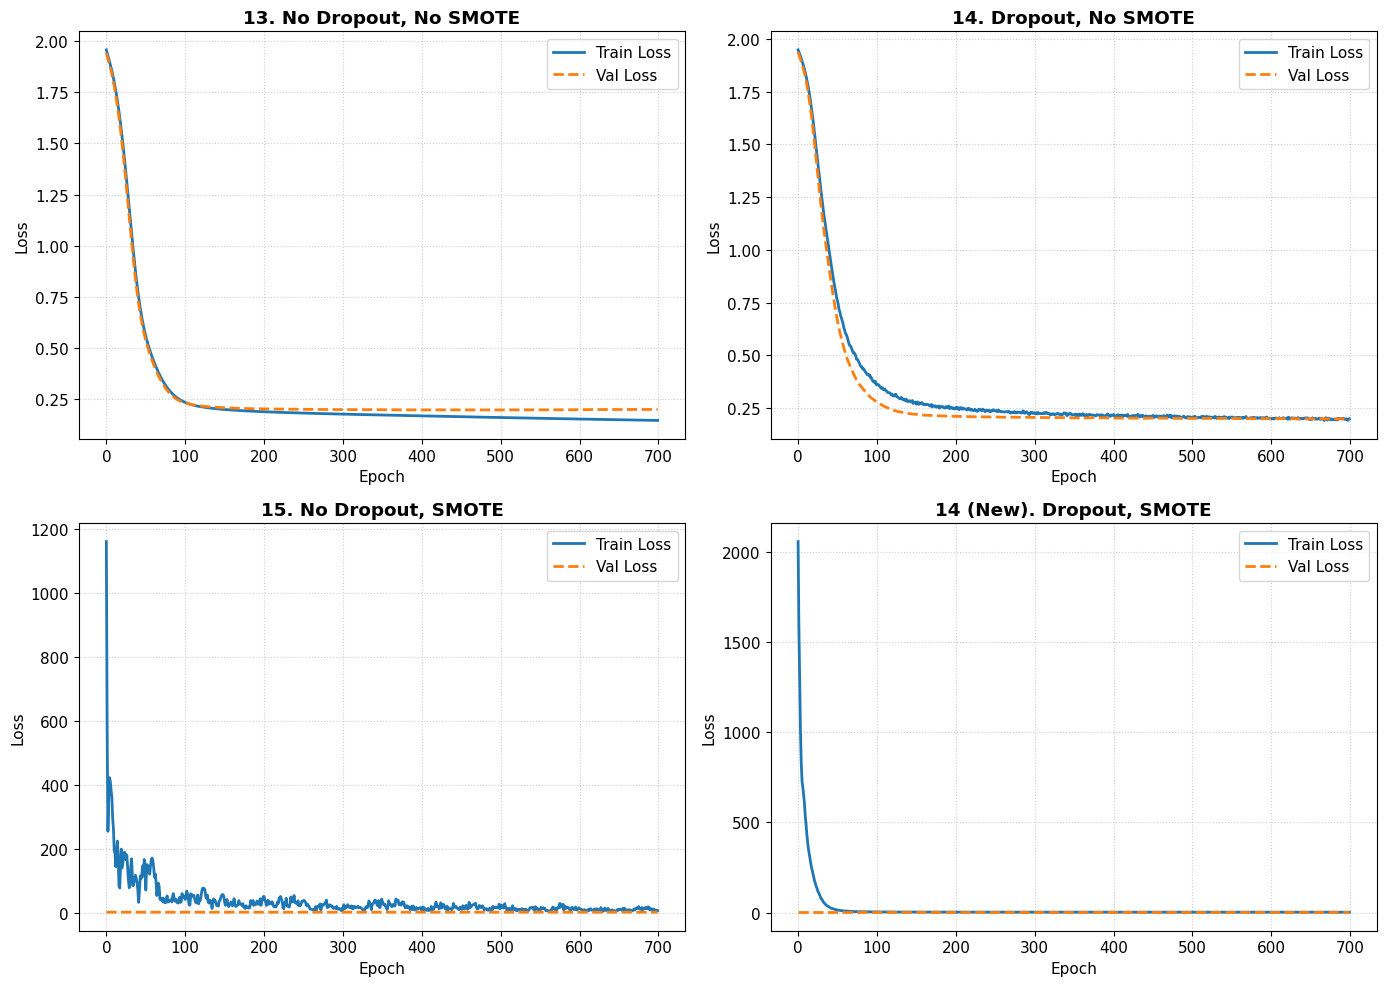

In [74]:
import matplotlib.pyplot as plt

# Cấu hình kích thước và kiểu dáng tổng thể cho biểu đồ
plt.figure(figsize=(14, 10))
plt.rcParams["font.size"] = 11

# ========================================================
# Kịch bản 1: No Dropout, No SMOTE (Đoạn 13)
# ========================================================
plt.subplot(2, 2, 1)
plt.plot(train_loss_no, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_no,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("13. No Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 2: Dropout, No SMOTE (Đoạn 14 cũ)
# ========================================================
plt.subplot(2, 2, 2)
plt.plot(train_loss_drop, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_drop,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("14. Dropout, No SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 3: No Dropout, SMOTE (Đoạn 15)
# ========================================================
plt.subplot(2, 2, 3)
plt.plot(
    train_loss_no_smote, label="Train Loss", color="#1f77b4", linewidth=2
)
plt.plot(
    val_loss_no_smote,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("15. No Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# ========================================================
# Kịch bản 4: Dropout, SMOTE (Đoạn 14 mới)
# ========================================================
plt.subplot(2, 2, 4)
plt.plot(train_loss_smote, label="Train Loss", color="#1f77b4", linewidth=2)
plt.plot(
    val_loss_smote,
    label="Val Loss",
    color="#ff7f0e",
    linestyle="--",
    linewidth=2,
)
plt.title("14 (New). Dropout, SMOTE", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Tự động căn chỉnh khoảng cách giữa các biểu đồ con để không bị đè chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

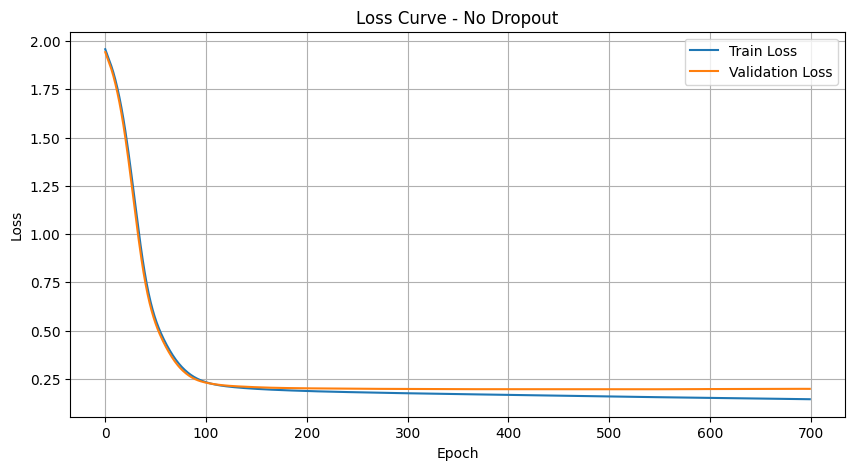

In [71]:
# =========================================
# LOSS CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_no,
    label="Train Loss"
)

plt.plot(
    val_loss_no,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =========================================
# LOSS CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_loss_drop,
    label="Train Loss"
)

plt.plot(
    val_loss_drop,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

VẼ ACCURACY CURVE

In [ ]:
# =========================================
# ACCURACY CURVE - NO DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_no,
    label="Train Accuracy"
)

plt.plot(
    val_acc_no,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - No Dropout")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =========================================
# ACCURACY CURVE - DROPOUT
# =========================================

plt.figure(figsize=(10,5))

plt.plot(
    train_acc_drop,
    label="Train Accuracy"
)

plt.plot(
    val_acc_drop,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curve - Dropout")

plt.legend()

plt.grid(True)

plt.show()

HÀM ĐÁNH GIÁ

In [ ]:
# =========================================
# 17. EVALUATE MODEL + CONFUSION MATRIX
# =========================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test):

    # =========================
    # EVALUATION MODE
    # =========================

    model.eval()

    with torch.no_grad():

        outputs = model(X_test)

        _, predictions = torch.max(outputs, 1)

    # =========================
    # NUMPY
    # =========================

    predictions = predictions.numpy()

    y_true = y_test.numpy()

    # =========================
    # ACCURACY
    # =========================

    accuracy = accuracy_score(
        y_true,
        predictions
    )

    print(f"\nAccuracy: {accuracy:.4f}")

    # =========================
    # CLASSIFICATION REPORT
    # =========================

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            predictions,
            target_names=encoder.classes_
        )
    )

    # =========================
    # CONFUSION MATRIX
    # =========================

    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=encoder.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format='d'
    )

    plt.title("Confusion Matrix")

    plt.xticks(rotation=45)

    plt.show()

ĐÁNH GIÁ NO DROPOUT

In [ ]:
# =========================================
# 18. TEST NO DROPOUT
# =========================================

print("===== NO DROPOUT =====")

evaluate_model(
    model_no_dropout,
    X_test,
    y_test
)

ĐÁNH GIÁ DROPOUT

In [ ]:
# =========================================
# 19. TEST DROPOUT
# =========================================

print("===== DROPOUT =====")

evaluate_model(
    model_dropout,
    X_test,
    y_test
)